In [2]:
# Standard Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Imports
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans,AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram,linkage

In [3]:
#load Iris dataset
iris=datasets.load_iris()
X=iris.data
y=iris.target
feature_names=iris.feature_names
df=pd.DataFrame(X,columns=feature_names)
df['target']=y
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
pd.DataFrame(X_scaled,columns=feature_names).head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


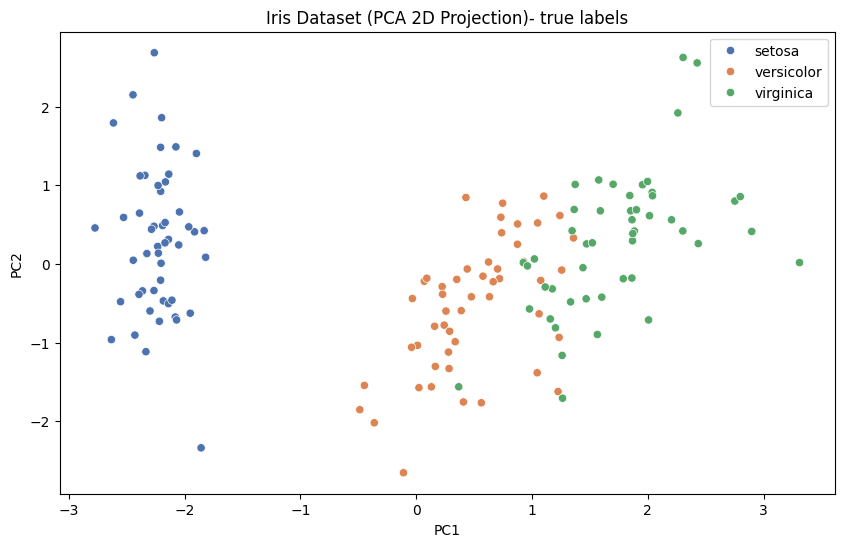

In [7]:
pca=PCA(n_components=2,random_state=42)
X_pca=pca.fit_transform(X_scaled)
plt.figure(figsize=(10,6))
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=iris.target_names[y],palette="deep")
plt.title('Iris Dataset (PCA 2D Projection)- true labels')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [10]:
#Elbow method (inertia) & silhouette for k=2..6
inertia=[]
sil_scores=[]
k=range(2,15)
for k in k:
  km=KMeans(n_clusters=k,random_state=42,n_init=10)
  labels=km.fit_predict(X_scaled)
  inertia.append(km.inertia_)
  sil_scores.append(silhouette_score(X_scaled,labels))

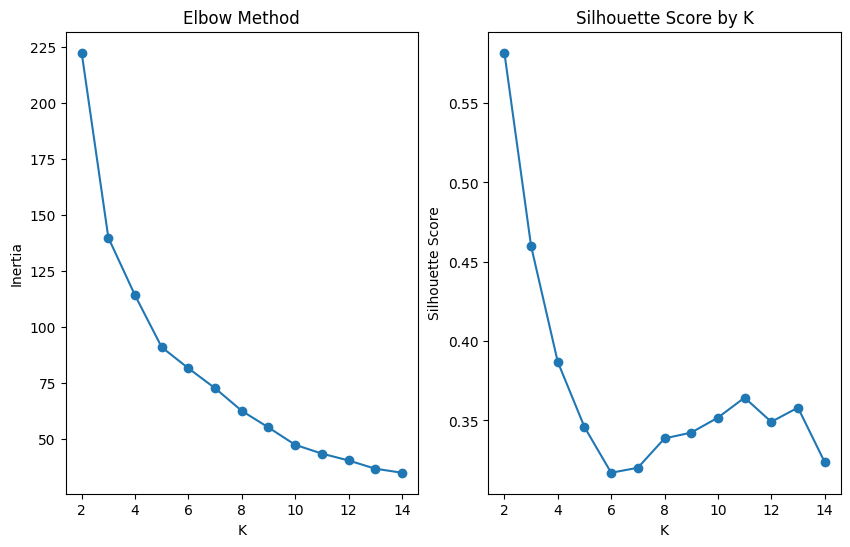

In [12]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
k_range_for_plot = range(2, 15) # Reconstruct the range of k values for plotting
plt.plot(k_range_for_plot,inertia,'-o')
plt.xlabel('K');
plt.ylabel('Inertia')
plt.title('Elbow Method')


plt.subplot(1,2,2)
plt.plot(k_range_for_plot,sil_scores,'-o')
plt.xlabel('K');
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by K')
plt.show()

In [19]:
#choose k=3 (Known for iris)

k=3
kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
klabels=kmeans.fit_predict(X_scaled)
print("Silhouette score (K=3)" ,round(silhouette_score(X_scaled ,klabels),3))

Silhouette score (K=3) 0.46


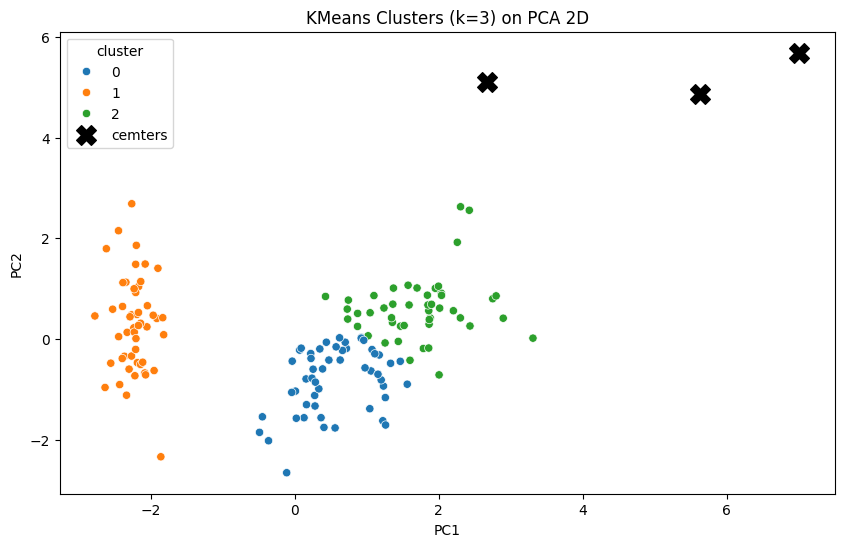

In [14]:
#Visualize KMeans Clusters on PCA Space
plt.figure(figsize=(10,6))
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=klabels,palette='tab10',legend='full')
centers=pca.transform(scaler.inverse_transform(kmeans.cluster_centers_)) # project cluster centers to PCA space
plt.scatter(centers[:,0],centers[:,1],c='black',s=200,marker='X',label='cemters')
plt.title(f'KMeans Clusters (k={k}) on PCA 2D');
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='cluster')
plt.show()

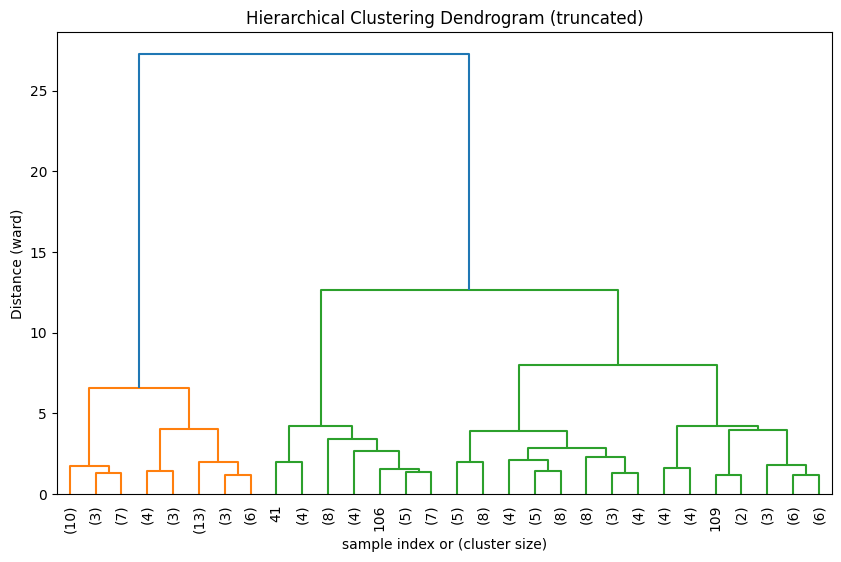

In [16]:
# linkage (ward) on scaled data for dendrogram

linked=linkage(X_scaled,method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked,truncate_mode='lastp',p=30,leaf_rotation=90,leaf_font_size=10.)
plt.title("Hierarchical Clustering Dendrogram (truncated)")
plt.xlabel("sample index or (cluster size)")
plt.ylabel('Distance (ward)')
plt.show()

In [18]:
# Fit Agglomerative Clustering with n_clusters=3
agg=AgglomerativeClustering(n_clusters=3,linkage='ward')
alabels=agg.fit_predict(X_scaled)
print("Silhouette score (agglomerative,n=3)" ,round(silhouette_score(X_scaled ,alabels),3))


Silhouette score (agglomerative,n=3) 0.447
